In [2]:
!pip install ultralytics pandas matplotlib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 64.4 MB/s eta 0:00:00


Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Brain Tumor.v1i.yolo26/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/yolo26s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp1-2, nbs=64, nms=False, opset=None, optimize=Fals

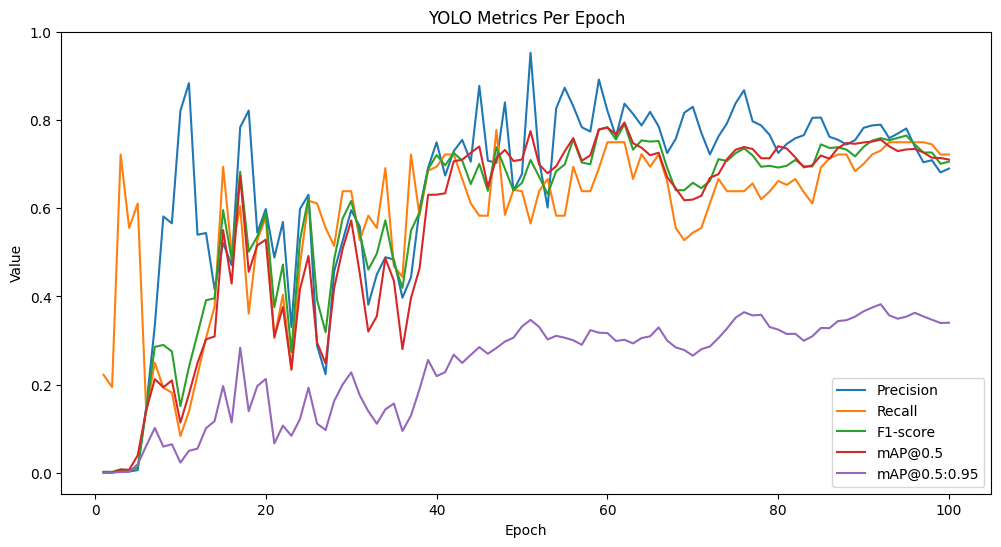

In [5]:
# ==========================================
# INSTALL LIBRARIES
# ==========================================
# !pip install ultralytics pandas matplotlib -q

# ==========================================s
# IMPORTS
# ==========================================
from ultralytics import YOLO
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# LOAD MODEL
# ==========================================
models = YOLO("/content/drive/MyDrive/yolo26s.pt")   # replace with your model

# ==========================================
# TRAIN MODEL
# ==========================================
results = models.train(
    # data="/content/drive/MyDrive/MRI.v3i.yolo26/data.yaml",     # dataset yaml
    data="/content/drive/MyDrive/Brain Tumor.v1i.yolo26/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    project="yolo_training",
    name="exp1"
)

# ==========================================
# LOAD TRAINING CSV
# Ultralytics automatically saves metrics
# after every epoch in results.csv
# ==========================================
# Correcting the csv_path to reflect the actual training run output directory
csv_path = "/content/runs/detect/yolo_training/exp1-2/results.csv"

df = pd.read_csv(csv_path)

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# ==========================================
# EXTRACT METRICS
# ==========================================
epochs = df["epoch"]

precision = df["metrics/precision(B)"]
recall = df["metrics/recall(B)"]
map50 = df["metrics/mAP50(B)"]
map5095 = df["metrics/mAP50-95(B)"]

# ==========================================
# CALCULATE F1 SCORE FOR EACH EPOCH
# ==========================================
f1_score = 2 * (precision * recall) / (precision + recall + 1e-8)

# Add F1 to dataframe
df["F1-score"] = f1_score

# ==========================================
# DISPLAY TABLE
# ==========================================
final_table = pd.DataFrame({
    "Epoch": epochs,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1_score,
    "mAP@0.5": map50,
    "mAP@0.5:0.95": map5095
})

print(final_table)

# ==========================================
# SAVE TABLE
# ==========================================
final_table.to_csv("epoch_metrics2-50.csv", index=False)

print("\nSaved as epoch_metrics2-50.csv")

# ==========================================
# PLOT METRICS
# ==========================================
plt.figure(figsize=(12,6))

plt.plot(epochs, precision, label="Precision")
plt.plot(epochs, recall, label="Recall")
plt.plot(epochs, f1_score, label="F1-score")
plt.plot(epochs, map50, label="mAP@0.5")
plt.plot(epochs, map5095, label="mAP@0.5:0.95")

plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("YOLO Metrics Per Epoch")
plt.legend()

plt.show()

In [6]:
print(models.info())

YOLO26s summary: 260 layers, 9,948,638 parameters, 0 gradients, 22.5 GFLOPs
(260, 9948638, 0, 22.498713600000002)


Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Brain Tumor.v1i.yolo26/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/yolo26m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp1-4, nbs=64, nms=False, opset=None, optimize=Fals

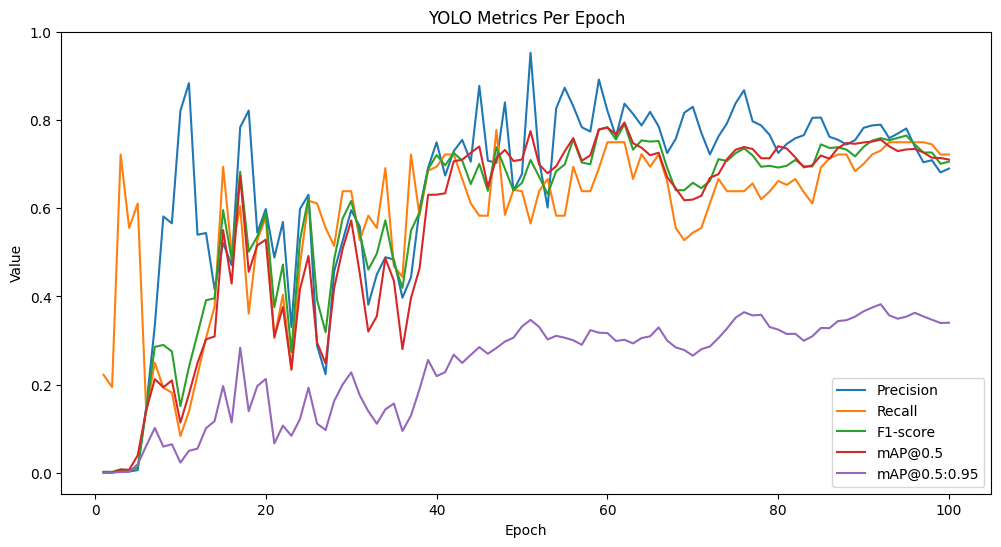

In [8]:
# ==========================================
# INSTALL LIBRARIES
# ==========================================
# !pip install ultralytics pandas matplotlib -q

# ==========================================s
# IMPORTS
# ==========================================
from ultralytics import YOLO
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# LOAD MODEL
# ==========================================
modelm = YOLO("/content/drive/MyDrive/yolo26m.pt")   # replace with your model

# ==========================================
# TRAIN MODEL
# ==========================================
results = modelm.train(
    # data="/content/drive/MyDrive/MRI.v3i.yolo26/data.yaml",     # dataset yaml
    data="/content/drive/MyDrive/Brain Tumor.v1 i.yolo26/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    project="yolo_training",
    name="exp1"
)

# ==========================================
# LOAD TRAINING CSV
# Ultralytics automatically saves metrics
# after every epoch in results.csv
# ==========================================
# Correcting the csv_path to reflect the actual training run output directory
csv_path = "/content/runs/detect/yolo_training/exp1-2/results.csv"

df = pd.read_csv(csv_path)

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# ==========================================
# EXTRACT METRICS
# ==========================================
epochs = df["epoch"]

precision = df["metrics/precision(B)"]
recall = df["metrics/recall(B)"]
map50 = df["metrics/mAP50(B)"]
map5095 = df["metrics/mAP50-95(B)"]

# ==========================================
# CALCULATE F1 SCORE FOR EACH EPOCH
# ==========================================
f1_score = 2 * (precision * recall) / (precision + recall + 1e-8)

# Add F1 to dataframe
df["F1-score"] = f1_score

# ==========================================
# DISPLAY TABLE
# ==========================================
final_table = pd.DataFrame({
    "Epoch": epochs,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1_score,
    "mAP@0.5": map50,
    "mAP@0.5:0.95": map5095
})

print(final_table)

# ==========================================
# SAVE TABLE
# ==========================================
final_table.to_csv("epoch_metrics3-100.csv", index=False)

print("\nSaved as epoch_metrics2-50.csv")

# ==========================================
# PLOT METRICS
# ==========================================
plt.figure(figsize=(12,6))

plt.plot(epochs, precision, label="Precision")
plt.plot(epochs, recall, label="Recall")
plt.plot(epochs, f1_score, label="F1-score")
plt.plot(epochs, map50, label="mAP@0.5")
plt.plot(epochs, map5095, label="mAP@0.5:0.95")

plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("YOLO Metrics Per Epoch")
plt.legend()

plt.show()

In [9]:
print(modelm.info())

YOLO26m summary: 280 layers, 21,774,430 parameters, 0 gradients, 74.7 GFLOPs
(280, 21774430, 0, 74.71800320000001)
